# MSCS 634 – Project Deliverable 2

## Regression Modeling and Performance Evaluation

**Student Name:** Nishan Pathak

**Course:** Advanced Big Data and Data Mining  
**Deliverable:** 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

In [2]:
url = "https://raw.githubusercontent.com/digvijay-m-s/Customer-Personality-Analysis/main/marketing_campaign.csv"
df = pd.read_csv(url, sep="\t")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


### Dataset Overview

The dataset used in this analysis is the Customer Personality Analysis dataset, which contains demographic and purchasing behavior data of customers.

Key variables include income, age, spending across different product categories, and customer interaction metrics such as web visits and purchases.

In [3]:
df['Income'] = df['Income'].fillna(df['Income'].median())
df = df.drop_duplicates()

### Data Cleaning

Missing values in the Income column were handled by replacing them with the median value. Duplicate records were also removed to ensure data quality and consistency for modeling.

In [4]:
df['Age'] = 2026 - df['Year_Birth']

### Feature Creation: Age

A new feature called Age was created using the Year_Birth column. This helps represent customer demographics in a more meaningful way for regression modeling.

In [5]:
df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

In [6]:
df['Children'] = df['Kidhome'] + df['Teenhome']

### Feature Engineering

Two new features were created to improve model performance:

- **Total_Spending**: Represents total customer expenditure across all product categories.
- **Children**: Combines Kidhome and Teenhome into a single feature to simplify household composition.

These features help reduce redundancy and improve the predictive power of the model.

In [7]:
features = [
    'Age',
    'Recency',
    'Kidhome',
    'Teenhome',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth',
    'Total_Spending',
    'Children'
]

X = df[features]
y = df['Income']

### Feature Selection

The target variable for this regression task is **Income**, as it is a continuous numeric variable suitable for prediction.

Relevant numerical features related to customer behavior and demographics were selected as predictors.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train-Test Split

The dataset was split into training (80%) and testing (20%) sets to evaluate model performance on unseen data.

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Feature Scaling

StandardScaler was applied to normalize the feature values. This ensures that all variables contribute equally to the model and is especially important for regularization methods like Ridge Regression.

In [10]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

In [11]:
lr_r2 = r2_score(y_test, y_pred_lr)
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)

print("Linear Regression R²:", lr_r2)
print("Linear Regression MSE:", lr_mse)
print("Linear Regression RMSE:", lr_rmse)

Linear Regression R²: 0.7666878677622786
Linear Regression MSE: 99431689.19212413
Linear Regression RMSE: 9971.54397233067


### Linear Regression Results

The Linear Regression model achieved an R² score of approximately 0.77, indicating that it explains about 77% of the variance in income.

The RMSE value (~9971) suggests the average prediction error in income values.

Overall, the model performs well and serves as a strong baseline.

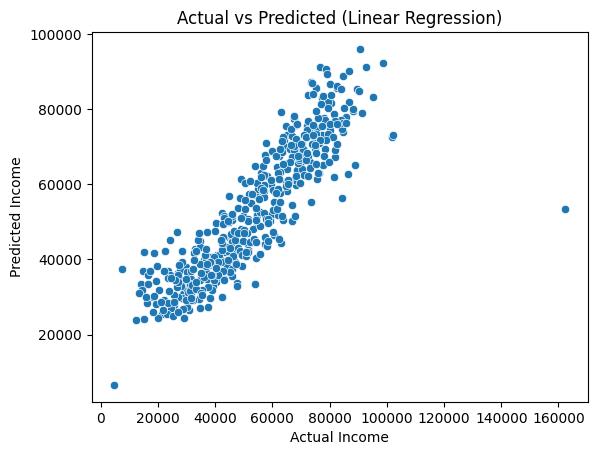

In [19]:
sns.scatterplot(x=y_test, y=y_pred_lr)
plt.xlabel("Actual Income")
plt.ylabel("Predicted Income")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

### Actual vs Predicted Values (Linear Regression)

This scatter plot compares the actual income values with the predicted values from the Linear Regression model.

Most points are clustered along an upward trend, indicating a strong positive relationship between actual and predicted values. This suggests that the model is performing well in capturing the underlying patterns in the data.

Some deviations from the trend line can be observed, indicating prediction errors, especially for a few extreme values. Overall, the model demonstrates good predictive performance.

In [12]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

In [13]:
ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(ridge_mse)

print("Ridge Regression R²:", ridge_r2)
print("Ridge Regression MSE:", ridge_mse)
print("Ridge Regression RMSE:", ridge_rmse)

Ridge Regression R²: 0.7666488653234639
Ridge Regression MSE: 99448311.03830402
Ridge Regression RMSE: 9972.377401517855


In [14]:
lr_cv_scores = cross_val_score(
    lr_model, scaler.fit_transform(X), y, cv=5, scoring='r2'
)

print("Linear Regression CV R² Scores:", lr_cv_scores)
print("Linear Regression Mean CV R²:", lr_cv_scores.mean())

Linear Regression CV R² Scores: [0.72923884 0.72031331 0.77687836 0.80227046 0.21472389]
Linear Regression Mean CV R²: 0.6486849733540236


In [15]:
ridge_cv_scores = cross_val_score(
    ridge_model, scaler.fit_transform(X), y, cv=5, scoring='r2'
)

print("Ridge Regression CV R² Scores:", ridge_cv_scores)
print("Ridge Regression Mean CV R²:", ridge_cv_scores.mean())

Ridge Regression CV R² Scores: [0.72930397 0.72027918 0.77687273 0.80229107 0.21474348]
Ridge Regression Mean CV R²: 0.6486980857699856


### Ridge Regression Results

The Ridge Regression model produced results very similar to Linear Regression, with nearly identical R² and RMSE values.

This suggests that multicollinearity is not significantly impacting the model, or that the dataset is already well-conditioned.

### Evaluation Summary Table

The table below compares the performance of Linear Regression and Ridge Regression using R², MSE, RMSE, and mean cross-validation R² scores.

In [16]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression'],
    'R2': [lr_r2, ridge_r2],
    'MSE': [lr_mse, ridge_mse],
    'RMSE': [lr_rmse, ridge_rmse],
    'CV Mean R2': [lr_cv_scores.mean(), ridge_cv_scores.mean()]
})

results

,Model,R2,MSE,RMSE,CV Mean R2
0,Linear Regression,0.766688,9.943169e+07,9971.543972,0.648685
1,Ridge Regression,0.766649,9.944831e+07,9972.377402,0.648698


### Cross-Validation Results

Cross-validation was performed using 5 folds to evaluate model generalization.

The average R² score (~0.65) is lower than the test R² (~0.77), indicating some variability in model performance across different data splits.

One fold showed a noticeably lower score, suggesting possible data variability or the presence of outliers. However, the overall model performance remains reasonably stable.

This difference between test and cross-validation scores suggests that while the model performs well, its performance may vary depending on the data used for training.

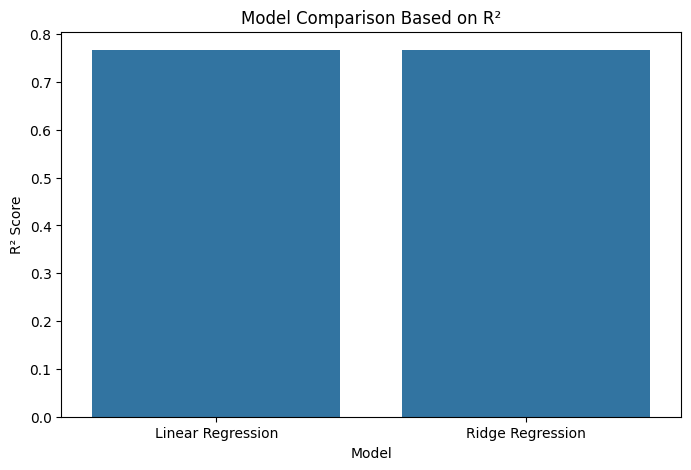

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='R2', data=results)
plt.title('Model Comparison Based on R²')
plt.ylabel('R² Score')
plt.show()

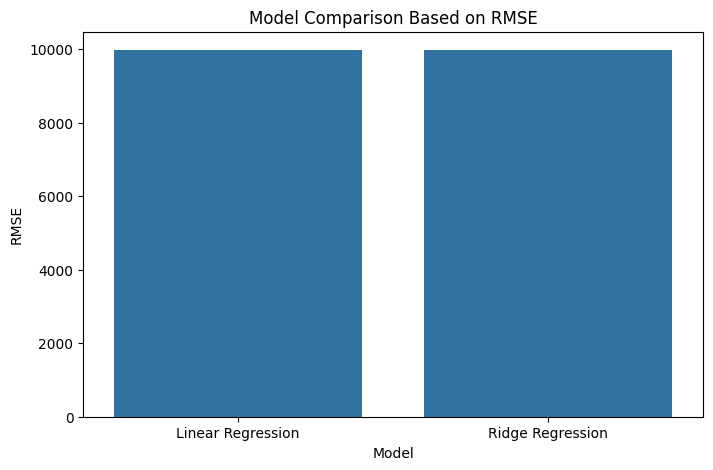

In [18]:
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='RMSE', data=results)
plt.title('Model Comparison Based on RMSE')
plt.ylabel('RMSE')
plt.show()

### Model Comparison

Both Linear Regression and Ridge Regression performed similarly across all evaluation metrics.

Since Ridge did not significantly improve performance, Linear Regression can be considered sufficient for this dataset.

### Conclusion and Insights

The regression models demonstrated strong predictive capability, with both Linear and Ridge Regression achieving high R² values.

Feature engineering played an important role in improving performance, particularly the addition of Total_Spending and Children.

Although both models performed similarly, Linear Regression is preferred due to its simplicity and comparable accuracy.

Future improvements could include adding categorical encoding or testing more advanced models to further improve performance.